In [1]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

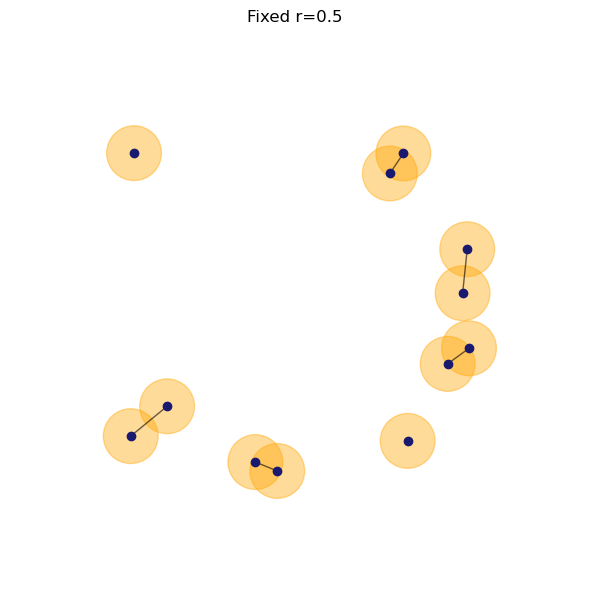

In [2]:
# Parameters
num_points = 12
radius = 0.5     # base circle radius
r_min = 2.5
r_max = 4.5

# Generate random positions in an annular region
angles = np.random.uniform(0, 2 * np.pi, num_points)
radii = np.random.uniform(r_min, r_max, num_points)
x_centers = radii * np.cos(angles)
y_centers = radii * np.sin(angles)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Plot circles and dots
for x, y in zip(x_centers, y_centers):
    circle = plt.Circle((x, y), radius, color='orange', alpha=0.4)
    ax.add_artist(circle)
    ax.plot(x, y, 'o', color='midnightblue', zorder=5)

# Draw lines between overlapping "larger" circles
for i in range(num_points):
    for j in range(i + 1, num_points):
        dx = x_centers[i] - x_centers[j]
        dy = y_centers[i] - y_centers[j]
        dist = np.hypot(dx, dy)
        if dist < 2 * radius:
            ax.plot([x_centers[i], x_centers[j]], [y_centers[i], y_centers[j]],
                    color='k', linewidth=1, alpha=0.6, zorder=3)

# Set axis limits to ensure all circles are visible
padding = radius + 0.2  # add a bit of extra space
limit = r_max + padding
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

# Aesthetics
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.title(f'Fixed r={radius}')
plt.show()


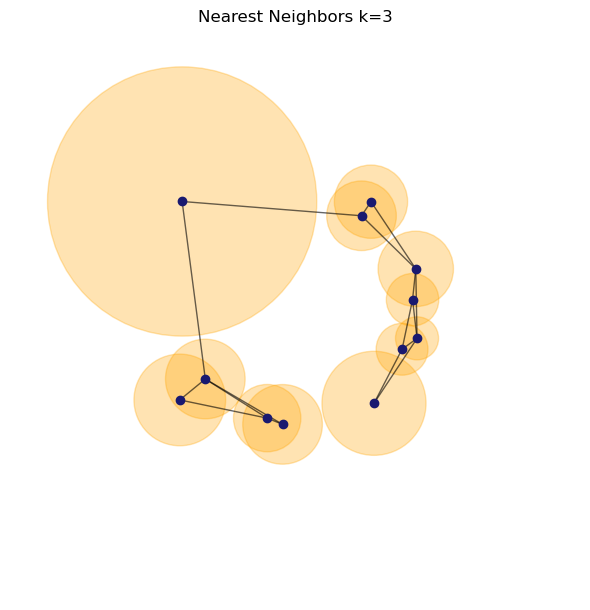

In [4]:
k = 3
# Generate random positions in an annular region
positions = np.column_stack((x_centers, y_centers))

# Compute pairwise distances
dists = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=2)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Track which lines we've already drawn (to avoid duplicates)
drawn_edges = set()

# Plot each point
for i in range(num_points):
    # Get indices of 3 nearest neighbors (exclude self)
    neighbor_indices = np.argsort(dists[i])[1:k]
    neighbor_dists = dists[i][neighbor_indices]
    avg_dist = np.mean(neighbor_dists)

    # Plot circle with radius = avg_dist
    x, y = positions[i]
    circle = plt.Circle((x, y), avg_dist*.75, color='orange', alpha=0.3)
    ax.add_artist(circle)

    # Plot centroid
    ax.plot(x, y, 'o', color='midnightblue', zorder=5)

    # Draw edges to 3 nearest neighbors
    for j in neighbor_indices:
        edge = tuple(sorted((i, j)))
        if edge not in drawn_edges:
            ax.plot([x, positions[j][0]], [y, positions[j][1]],
                    color='k', linewidth=1, alpha=0.6, zorder=3)
            drawn_edges.add(edge)

# Set axis limits to fit all objects
max_radius = np.max(dists) / 3  # safe bound for largest circle radius
limit = r_max + max_radius + 0.5
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

# Aesthetics
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.title(f'Nearest Neighbors k={3}')

plt.show()